In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#import matplotlib.colors as mcolors
#from numpy.polynomial import Polynomial
import seaborn as sns
#import math
import os

import warnings
warnings.filterwarnings("ignore")



In [2]:
# List of AOSLOs to process
AOSLO_list = [
    '4078_right_retina_Confocal_RPE_2023-09-09',
    '5181_left_retina_Confocal_RPE_IS_2023-09-10',
    '8323_right_retina_confocal_RPE_2023-09-13',
    '2538_right_retina_Confocal_RPE_2023-09-10',
    '4017_left_retina_Confocal_RPE_2023-09-10',
    '4064_od_retina_montaged_2023',
    '4571_left_retina_Confocal_RPE_IS_2023_09_09',
    '5160_right_retina_2024',
    '5160_right_retina_Confocal_RPE_2023-09-10',
    '5163_right_retina_RPE_2023-06-08',
    '5163_right_retina_2024',
    '5165_right_retina_RPE_2023-06-08',
    '5188_right_retina_Confocal_RPE_2023-09-10',
    '5225_right_retina_2024',
    '5232_right_retina_2024',
    #'5213_right_retina_2024_session198',
    #'5214_right_retina_2024_session205'
]




In [3]:
# List of AOSLOs to process
# AOSLO_list = [
#     '4078_right_retina_Confocal_RPE_2023-09-09',
#     '8323_right_retina_confocal_RPE_2023-09-13',
#     '2538_right_retina_Confocal_RPE_2023-09-10',
#     '4064_od_retina_montaged_2023'
# ]

# # Setting up the subplots
# nrows, ncols = 2, 2
# fig, axs = plt.subplots(nrows, ncols, figsize=(10, 10))



In [4]:
# # List of AOSLOs to process
# AOSLO_list = ['5181_left_retina_Confocal_RPE_IS_2023-09-10',
#               '8323_right_retina_confocal_RPE_2023-09-13',]

# # # Setting up the subplots
# nrows, ncols = 1, 2
# fig, axs = plt.subplots(nrows, ncols, figsize=(10, 5))

In [5]:
# Confocal images plotting

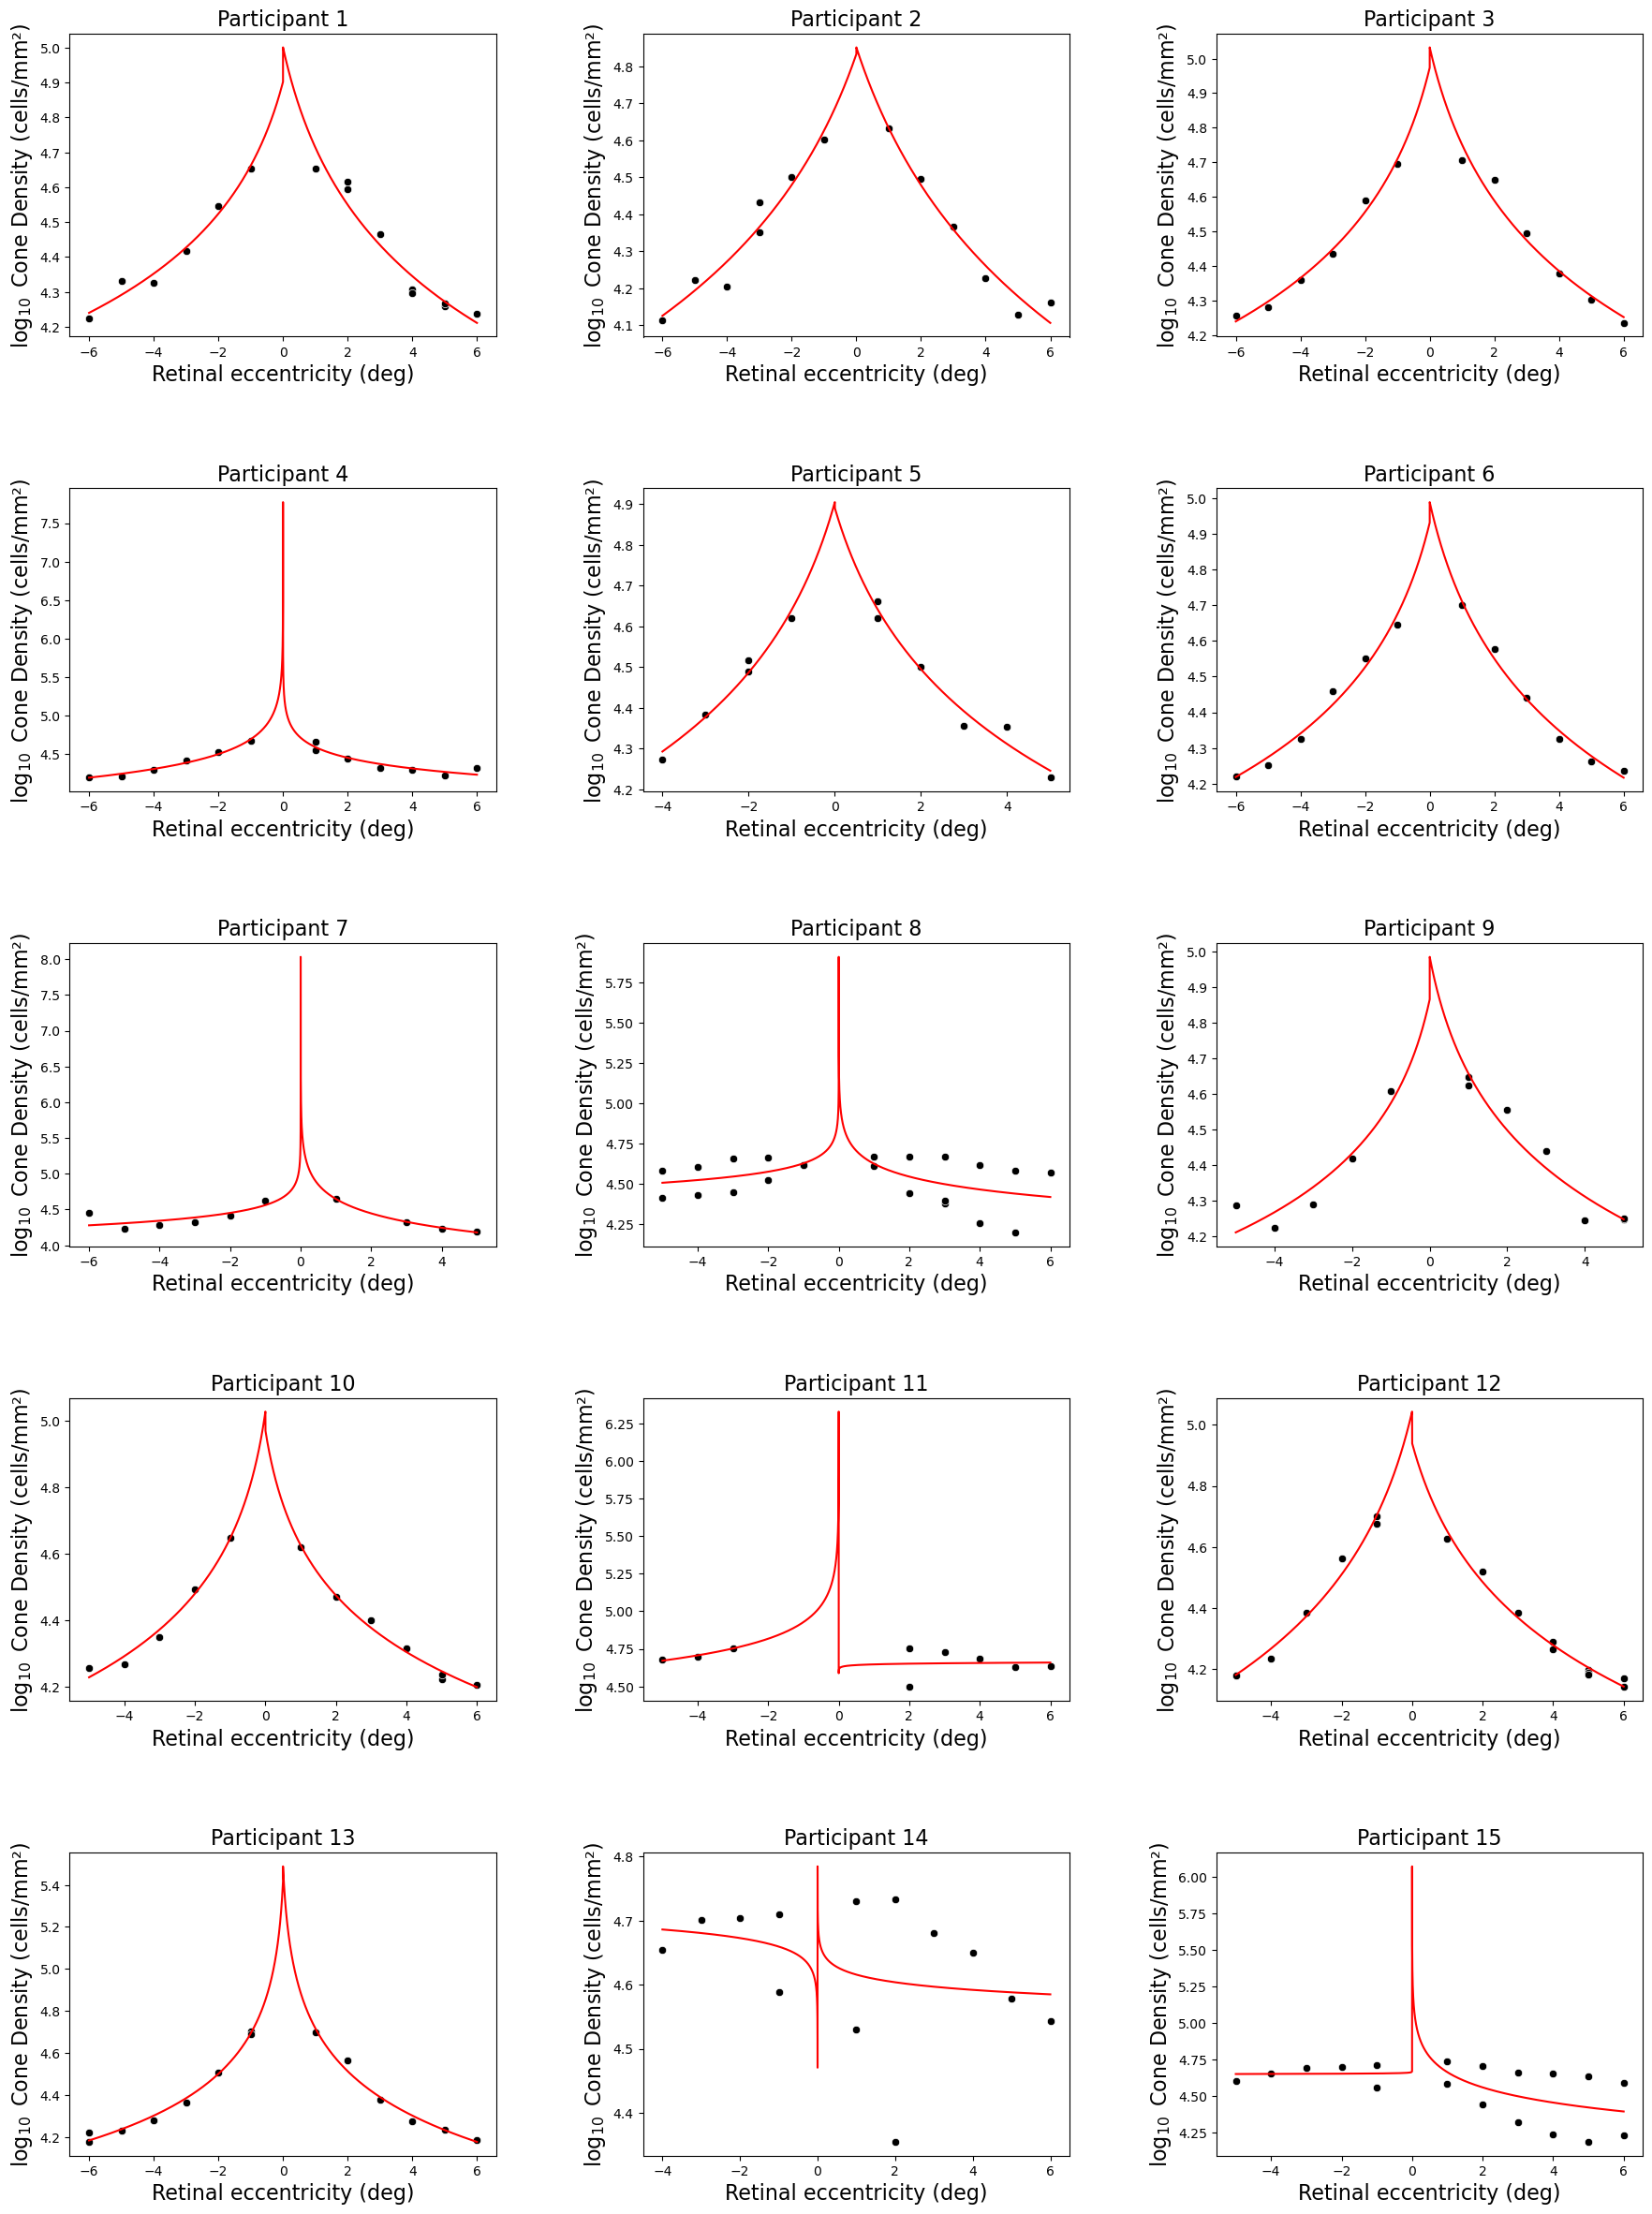

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit


def asymmetric_power_law(r_i, kappa, k_s, pi_n, pi_t, p_s, p_ns, p_ts, rho, r_s, e_i):
    """
    Asymmetric power law function for predicting density.

    Parameters:
    - r_i: Eccentricity (negative values for nasal)
    - kappa: Fixed effect intercept
    - k_s: Random intercept
    - pi_n: Fixed-effect exponent for the nasal visual field
    - pi_t: Fixed-effect exponent for the temporal visual field
    - p_s: Participant-specific fixed effect
    - p_ns: Random participant error for the nasal fixed effect
    - p_ts: Random participant error for the temporal fixed effect
    - rho: Fixed offset
    - r_s: Random offset

    Returns:
    - log(d_i): Log of predicted density
    """
    return np.where(
        r_i >= 0,
        kappa + k_s + ((pi_n + p_s) * np.log(np.abs(r_i) + (rho + r_s))) + e_i,
        kappa + k_s + ((pi_n - pi_t + p_ns - p_ts) * np.log(rho + r_s) + 
                      (pi_t + p_ts) * np.log(np.abs(r_i) + (rho + r_s))) + e_i
    )

# Setting up the subplots
nrows, ncols = 5, 3
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 24))
axs = axs.flatten()  # Flatten to easily iterate over all subplots

# Loop through each AOSLO and corresponding axis
for i, AOSLO in enumerate(AOSLO_list):
    # Read the data from CSV
    data = pd.read_csv(f'~/thesis_src/confocal_modality/analysis/csv_files/{AOSLO}.csv')
    
    data[['DegreeX', 'DegreeY']] = data['Degree'].str.strip('()').str.split(', ', expand=True)
    data['DegreeX'] = data['DegreeX'].astype(float)
    data['DegreeY'] = data['DegreeY'].astype(float)

    # Filter the data to include only points where the y-coordinate is 0 and within the x range [-6, 6]
    data_filtered = data[(data['DegreeY'] == 0) & (data['DegreeX'] >= -6) & (data['DegreeX'] <= 6) & (data['DegreeX'] != 0)].copy()
    #data_filtered = data[(data['DegreeX'] >= -6) & (data['DegreeX'] <= 6) & (data['DegreeX'] != 0)].copy()


    # Extract x-coordinates and y-values for fitting
    x = data_filtered['DegreeX'].values
    y = data_filtered['Predicted Cell Density'].values




    # Initial parameter guess
    p0 = [1, 0, -0.5, -0.5, 0, 0, 0, 0.1, 0, 0]

    # Parameter bounds
    bounds = ([-6, -1, -1, -1, -1, -1, -1, 0.01, -1, -1], [6, 1, 0, 0, 1, 1, 1, 1, 1, 1])

    
    # Fit the asymmetric power function
    popt, _ = curve_fit(asymmetric_power_law, x, y, p0=p0, bounds=bounds, maxfev=10000)

    # Generate x values for plotting the fitted function
    x_fit = np.linspace(min(x), max(x), 999000) # -6 to +6
    #print(x_fit)
    y_fit = asymmetric_power_law(x_fit, *popt)

    # Scatter plot of the original data
    sns.scatterplot(x=x, y=y, marker="o", color="black", ax=axs[i])

    # Plot the fitted asymmetric power function
    axs[i].plot(x_fit, y_fit, color='red')

    # Set the title for each subplot
    axs[i].set_title(f'Participant {i+1}', fontsize=16)

    # Setting common labels
    axs[i].set_xlabel("Retinal eccentricity (deg)", fontsize=16)
    axs[i].set_ylabel(r"$\log_{10}$ Cone Density (cells/mm²)", fontsize=16)





# Adjust layout to prevent overlap
#plt.tight_layout()
plt.tight_layout(pad=2.0, w_pad=6, h_pad=6)
plt.show()

if not os.path.exists('plots'):
    os.makedirs('plots')
    
fig.savefig('plots/confocal_2d_plots.png', format='png', dpi=300, bbox_inches='tight')


# 3D plots using Confocal images

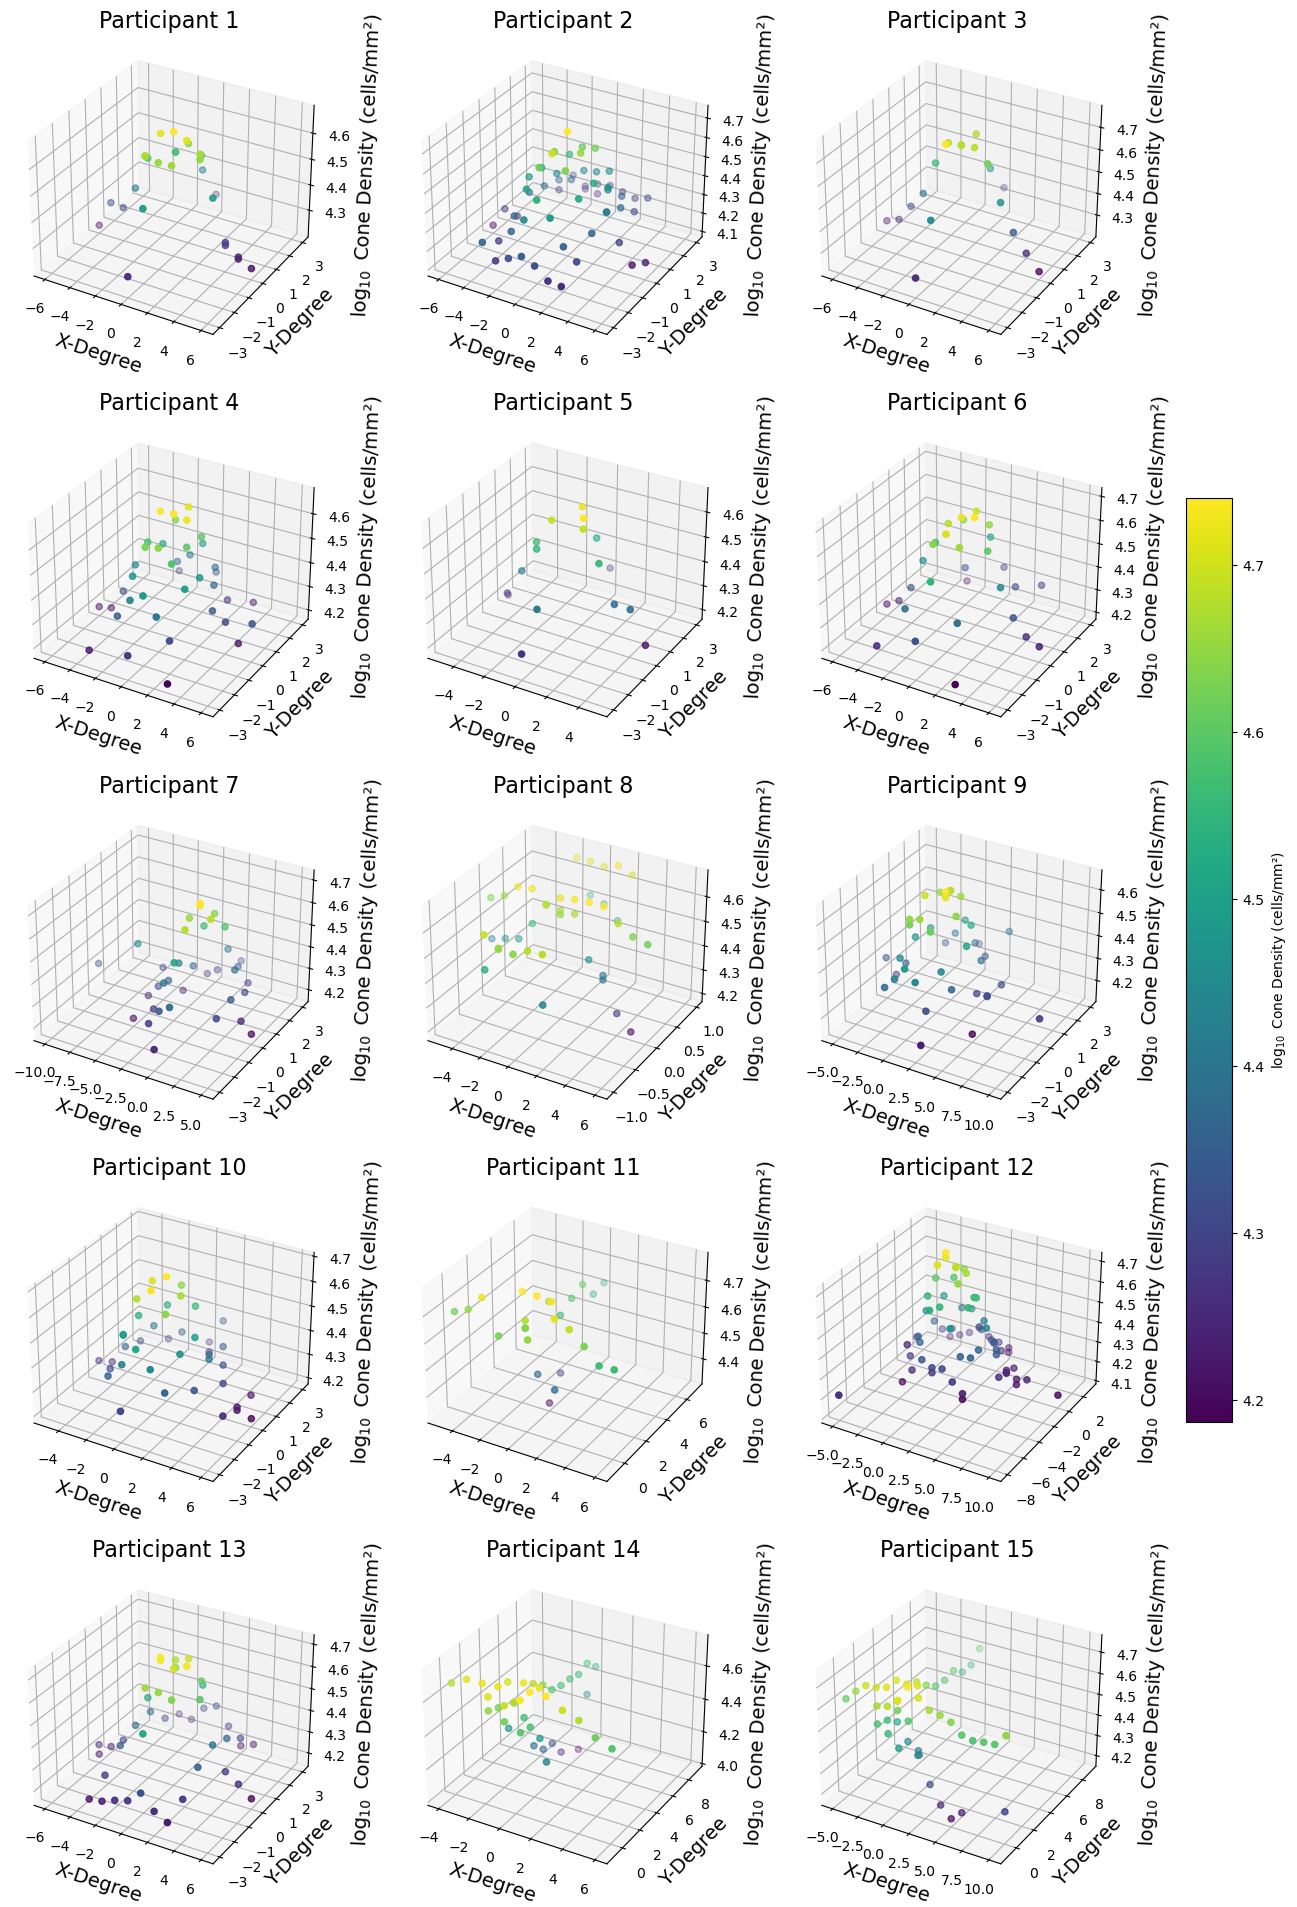

In [7]:
# Setting up the subplots
# nrows, ncols = 5, 3
# fig, axs = plt.subplots(nrows, ncols, figsize=(18, 24))
# axs = axs.flatten()  # Flatten to easily iterate over all subplots

fig = plt.figure(figsize=(18, 24))

for i, AOSLO in enumerate(AOSLO_list):
    # Read the data from CSV
    data = pd.read_csv(f'~/thesis_src/confocal_modality/analysis/csv_files/{AOSLO}.csv')

    # Extract DegreeX and DegreeY from the 'Degree' column
    data[['DegreeX', 'DegreeY']] = data['Degree'].str.strip('()').str.split(', ', expand=True)
    data['DegreeX'] = data['DegreeX'].astype(int)
    data['DegreeY'] = data['DegreeY'].astype(int)

    # Add a subplot for each AOSLO
    ax = fig.add_subplot(nrows, ncols, i + 1, projection='3d')

    # Scatter plot with color mapping
    sc = ax.scatter(data['DegreeX'], data['DegreeY'], data['Predicted Cell Density'],
                    c=data['Predicted Cell Density'], cmap='viridis', marker='o')

    # Set axis labels and title
    ax.set_xlabel('X-Degree', fontsize=14)
    ax.set_ylabel('Y-Degree', fontsize=14)
    ax.set_zlabel(r"$\log_{10}$ Cone Density (cells/mm²)", fontsize=14)
    #ax.set_title(AOSLO)
    ax.set_title(f'Participant {i+1}', fontsize=16)

# Add a color bar to the entire figure
fig.colorbar(sc, ax=fig.get_axes(), shrink=0.5, aspect=20, label=r"$\log_{10}$ Cone Density (cells/mm²)")


#plt.tight_layout()
#plt.tight_layout(pad=0, w_pad=2, h_pad=2)
plt.show()

if not os.path.exists('plots'):
    os.makedirs('plots')

fig.savefig('plots/confocal_3d_plots.png', format='png', dpi=300, bbox_inches='tight')

# Contour plots using confocal images

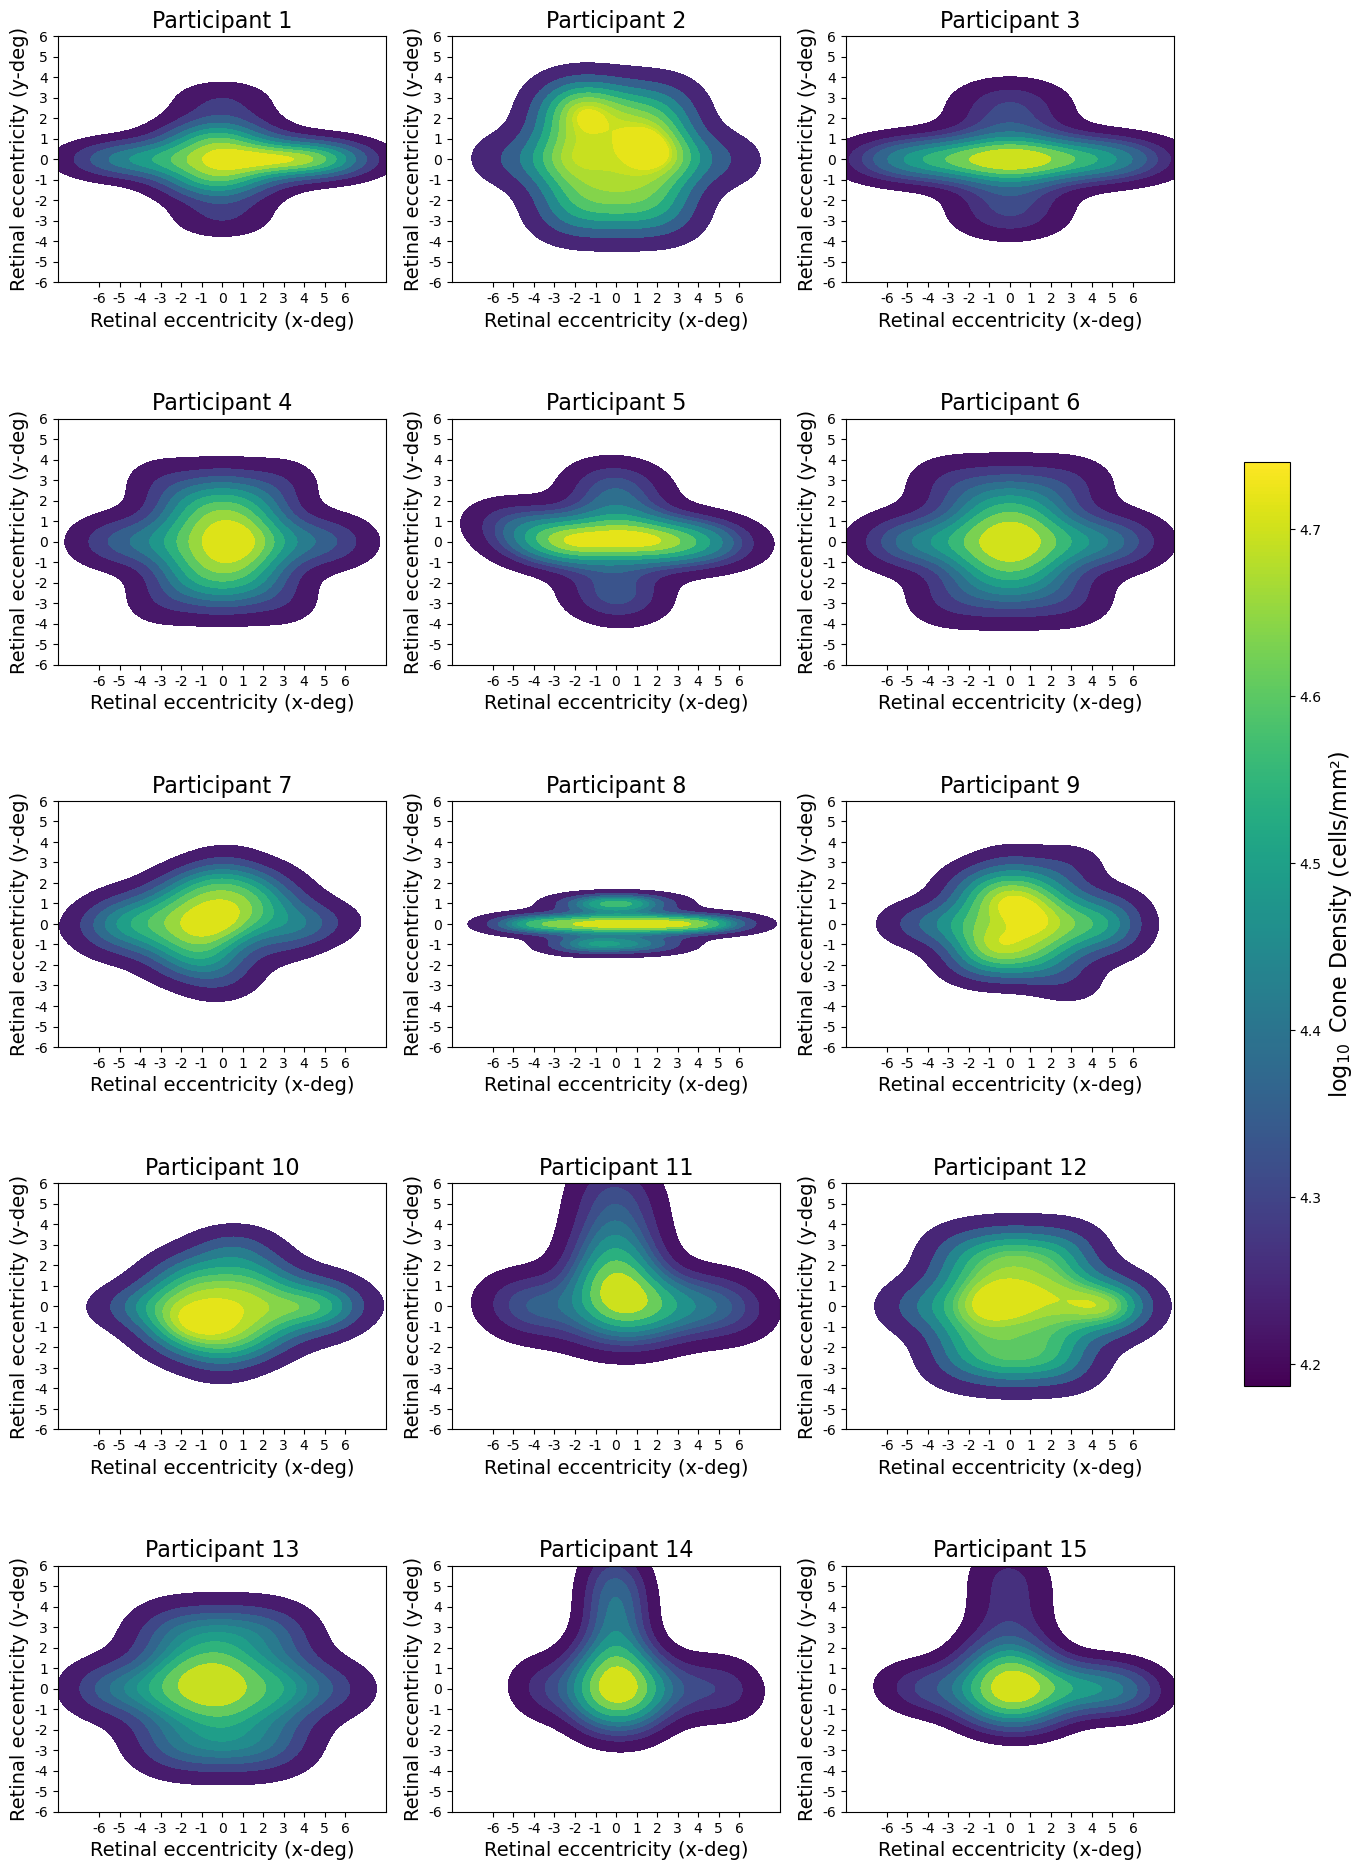

In [8]:
# Setting up the subplots
nrows, ncols = 5, 3
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 24))
axs = axs.flatten()  # Flatten to easily iterate over all subplots

x_ticks = range(-6, 7)
y_ticks = range(-6, 7)

# Loop through each AOSLO and corresponding axis
for i, AOSLO in enumerate(AOSLO_list):
    # Read the data from CSV
    data = pd.read_csv(f'~/thesis_src/confocal_modality/analysis/csv_files/{AOSLO}.csv')

    # Extract DegreeX and DegreeY from the 'Degree' column
    data[['DegreeX', 'DegreeY']] = data['Degree'].str.strip('()').str.split(', ', expand=True)
    data['DegreeX'] = data['DegreeX'].astype(int)
    data['DegreeY'] = data['DegreeY'].astype(int)
    

    # Filter the data
    filtered_data = data[(data['DegreeX'] >= -6) & (data['DegreeX'] <= 6) &
                         (data['DegreeY'] >= -6) & (data['DegreeY'] <= 6)]


    # Create a contour plot
    sns.kdeplot(
        x=filtered_data['DegreeX'], y=filtered_data['DegreeY'], 
        weights=filtered_data['Predicted Cell Density'], cmap="viridis", fill=True, ax=axs[i]
    )

    # Set the title for each subplot
    #axs[i].set_title(AOSLO)

    # Set axis labels
    axs[i].set_xlabel("Retinal eccentricity (x-deg)", fontsize=14)
    axs[i].set_ylabel("Retinal eccentricity (y-deg)", fontsize=14)
    axs[i].set_xticks(x_ticks)
    axs[i].set_xticklabels(x_ticks)
    axs[i].set_yticks(y_ticks)
    axs[i].set_yticklabels(y_ticks)
    
    axs[i].set_aspect('equal', adjustable='box')
    axs[i].set_xlim([-8, 8])
    axs[i].set_ylim([-6, 6])
    axs[i].set_title(f'Participant {i+1}', fontsize=16)

# Adjust layout to prevent overlap
#plt.tight_layout()

# Add a color bar to the entire figure
norm = plt.Normalize(vmin=filtered_data['Predicted Cell Density'].min(), vmax=filtered_data['Predicted Cell Density'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=fig.get_axes(), shrink=0.5, aspect=20)#, label=r"$\log_{10}$ Cone Density (cells/mm²)")
cbar.set_label(r"$\log_{10}$ Cone Density (cells/mm²)", fontsize=16)
plt.show()

if not os.path.exists('plots'):
    os.makedirs('plots')

fig.savefig('plots/confocal_contour_plots.png', format='png', dpi=300, bbox_inches='tight')

# Average cone inner-segment area using Confocal images

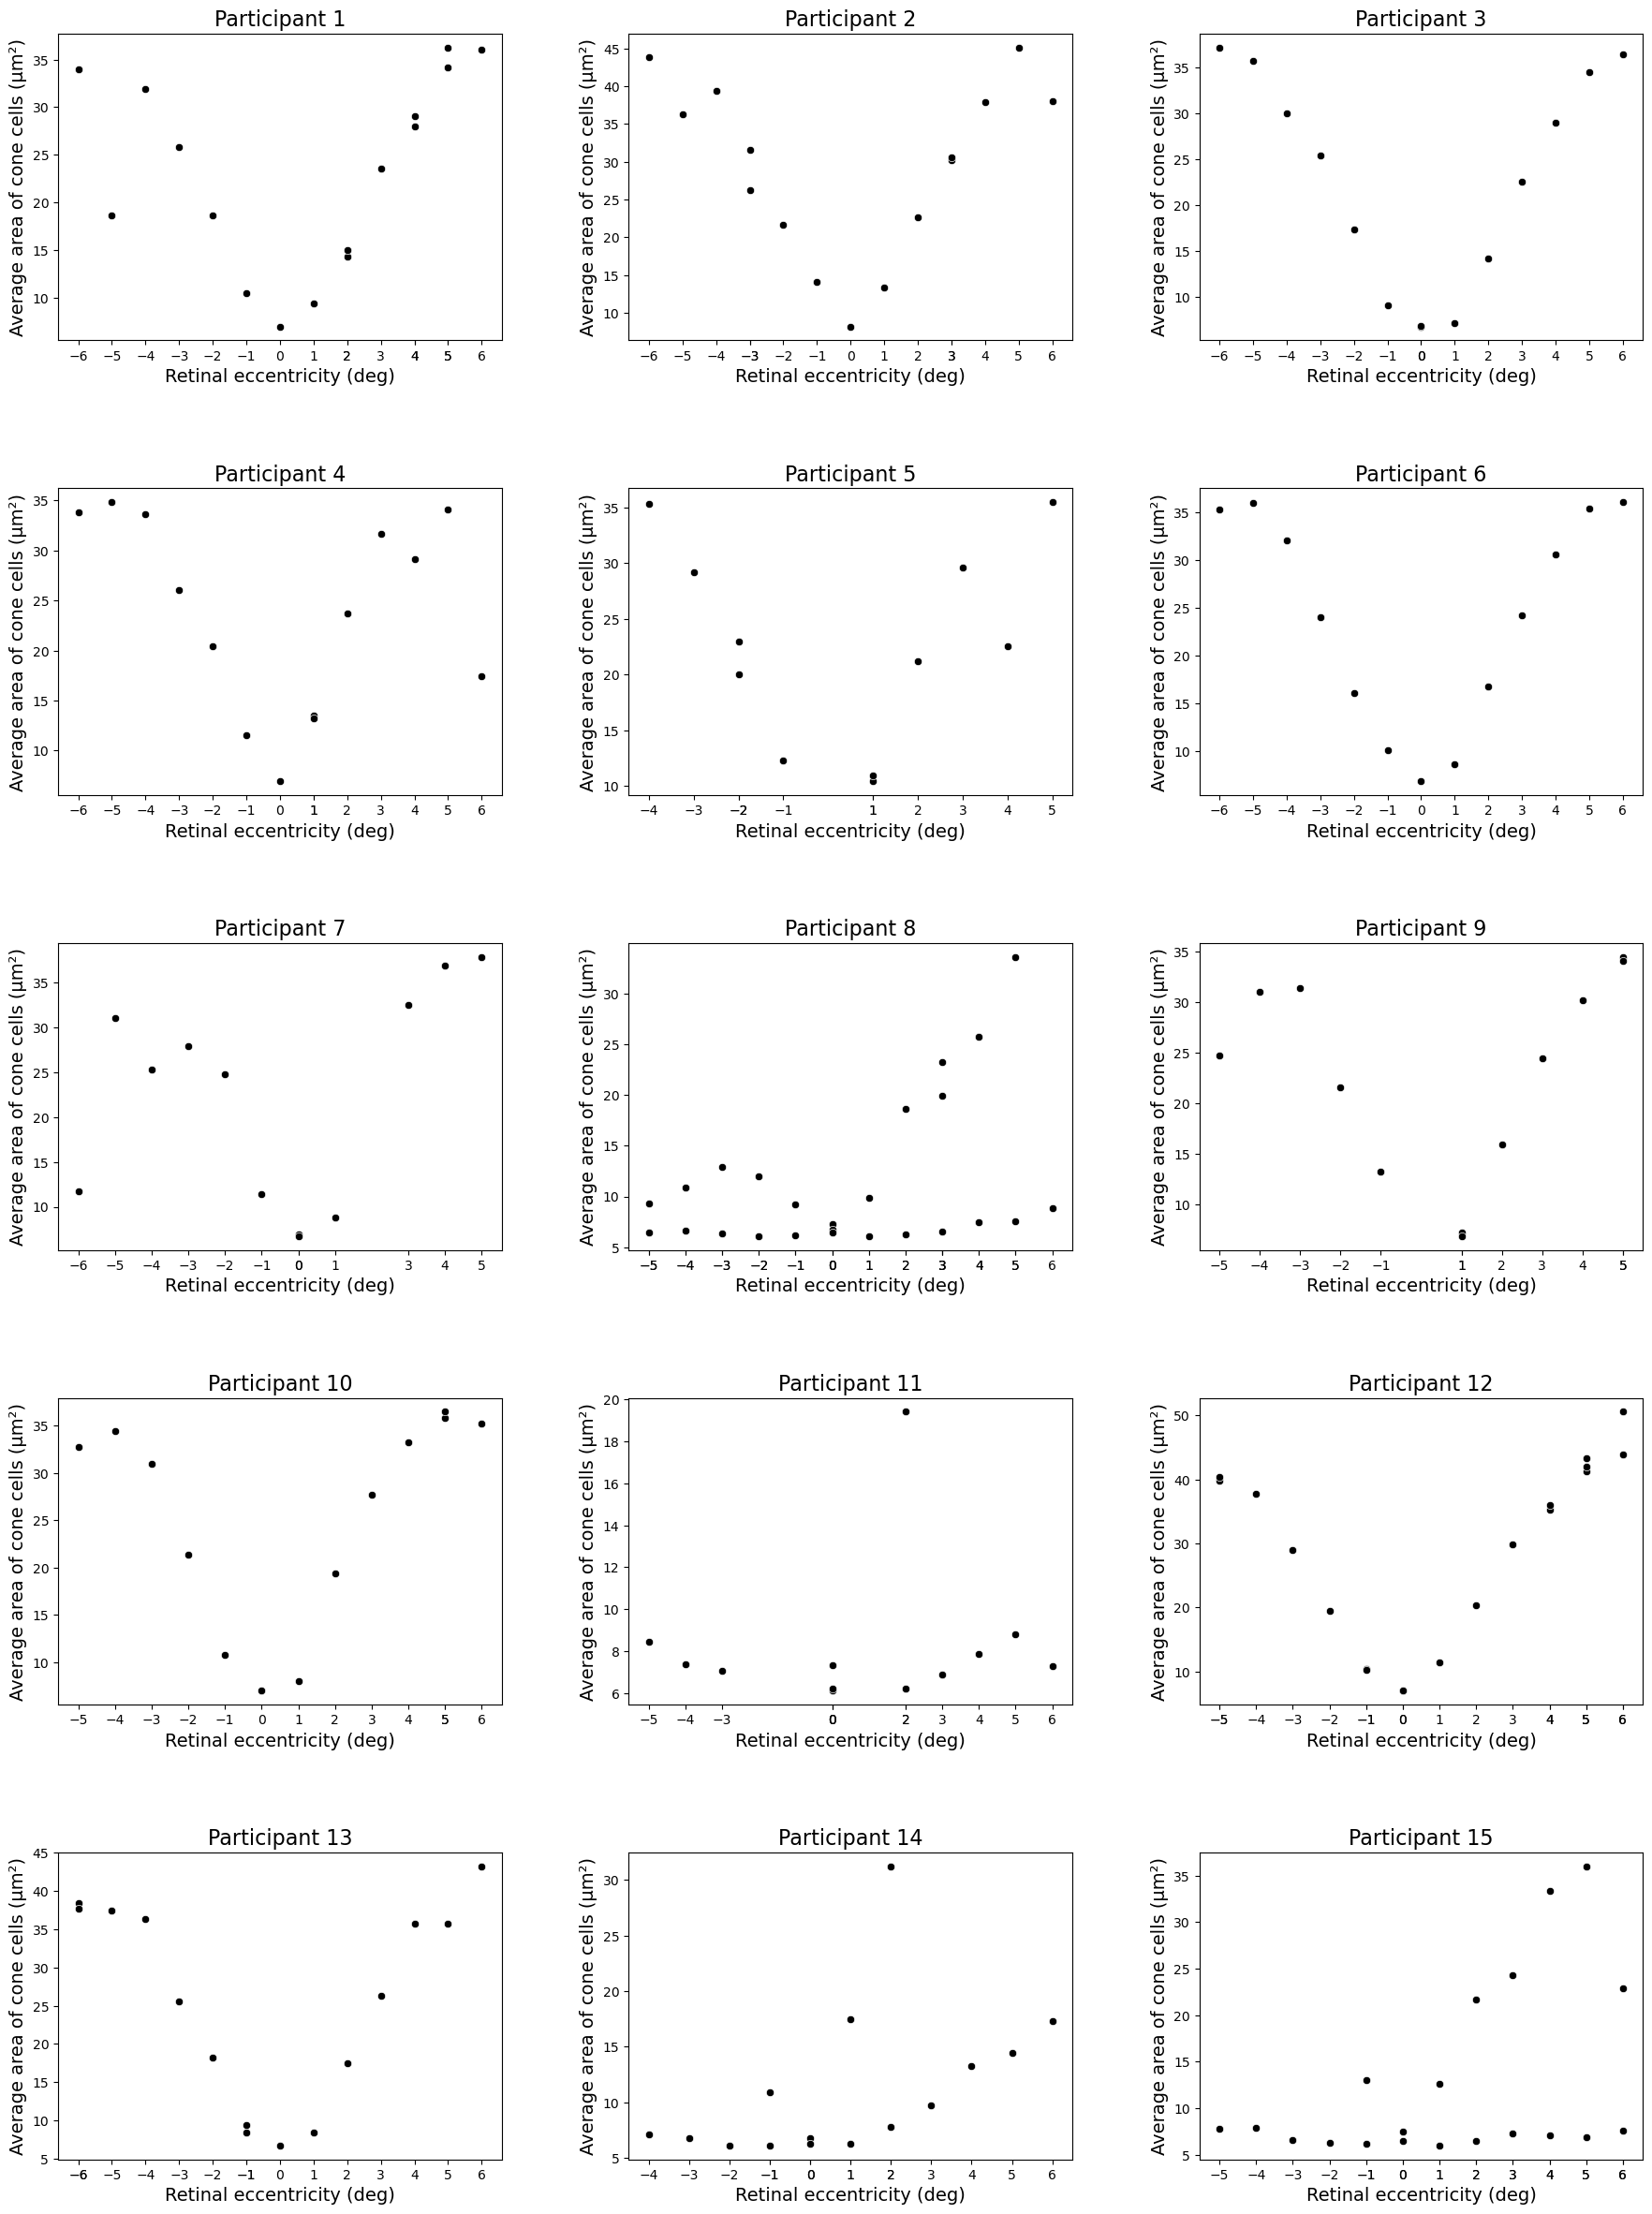

In [9]:
# Setting up the subplots
nrows, ncols = 5, 3
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 24))
axs = axs.flatten()  # Flatten to easily iterate over all subplots

for i, AOSLO in enumerate(AOSLO_list):
    # Read the data from CSV
    data = pd.read_csv(f'~/thesis_src/confocal_modality/analysis/csv_files/{AOSLO}.csv')
    
    
    data[['DegreeX', 'DegreeY']] = data['Degree'].str.strip('()').str.split(', ', expand=True)
    data['DegreeX'] = data['DegreeX'].astype(int)
    data['DegreeY'] = data['DegreeY'].astype(int)

    # Filter the data to include only points where the y-coordinate is 0 and within the x range [-6, 6]
    data_filtered = data[(data['DegreeY'] == 0) & (data['DegreeX'] >= -6) & (data['DegreeX'] <= 6)].copy()

    # Extract x-coordinates for plotting
    data_filtered['X'] = data_filtered['DegreeX']


    # Scatter plot of the original data
    sns.scatterplot(x=data_filtered['X'], y=data_filtered['Average cell Area'], marker="o", color="black", ax=axs[i])
    

    # Set the title for each subplot
    #axs[i].set_title(AOSLO)

    # Setting common labels
    axs[i].set_xlabel("Retinal eccentricity (deg)", fontsize=14)
    axs[i].set_xticks(data_filtered['X'])
    #axs[i].set_xticklabels(data['Degree'], rotation=90)
    axs[i].set_ylabel("Average area of cone cells (μm²)", fontsize=14)
    axs[i].grid(False)
    axs[i].set_title(f'Participant {i+1}', fontsize=16)

# Adjust layout to prevent overlap
#plt.tight_layout()
plt.tight_layout(pad=2.0, w_pad=6, h_pad=6)
plt.show()

if not os.path.exists('plots'):
    os.makedirs('plots')

fig.savefig('plots/confocal_area_plots.png', format='png', dpi=300, bbox_inches='tight')

# Calculated data plotting 

# 2D plot with Asymmetric power law fit using calculated images

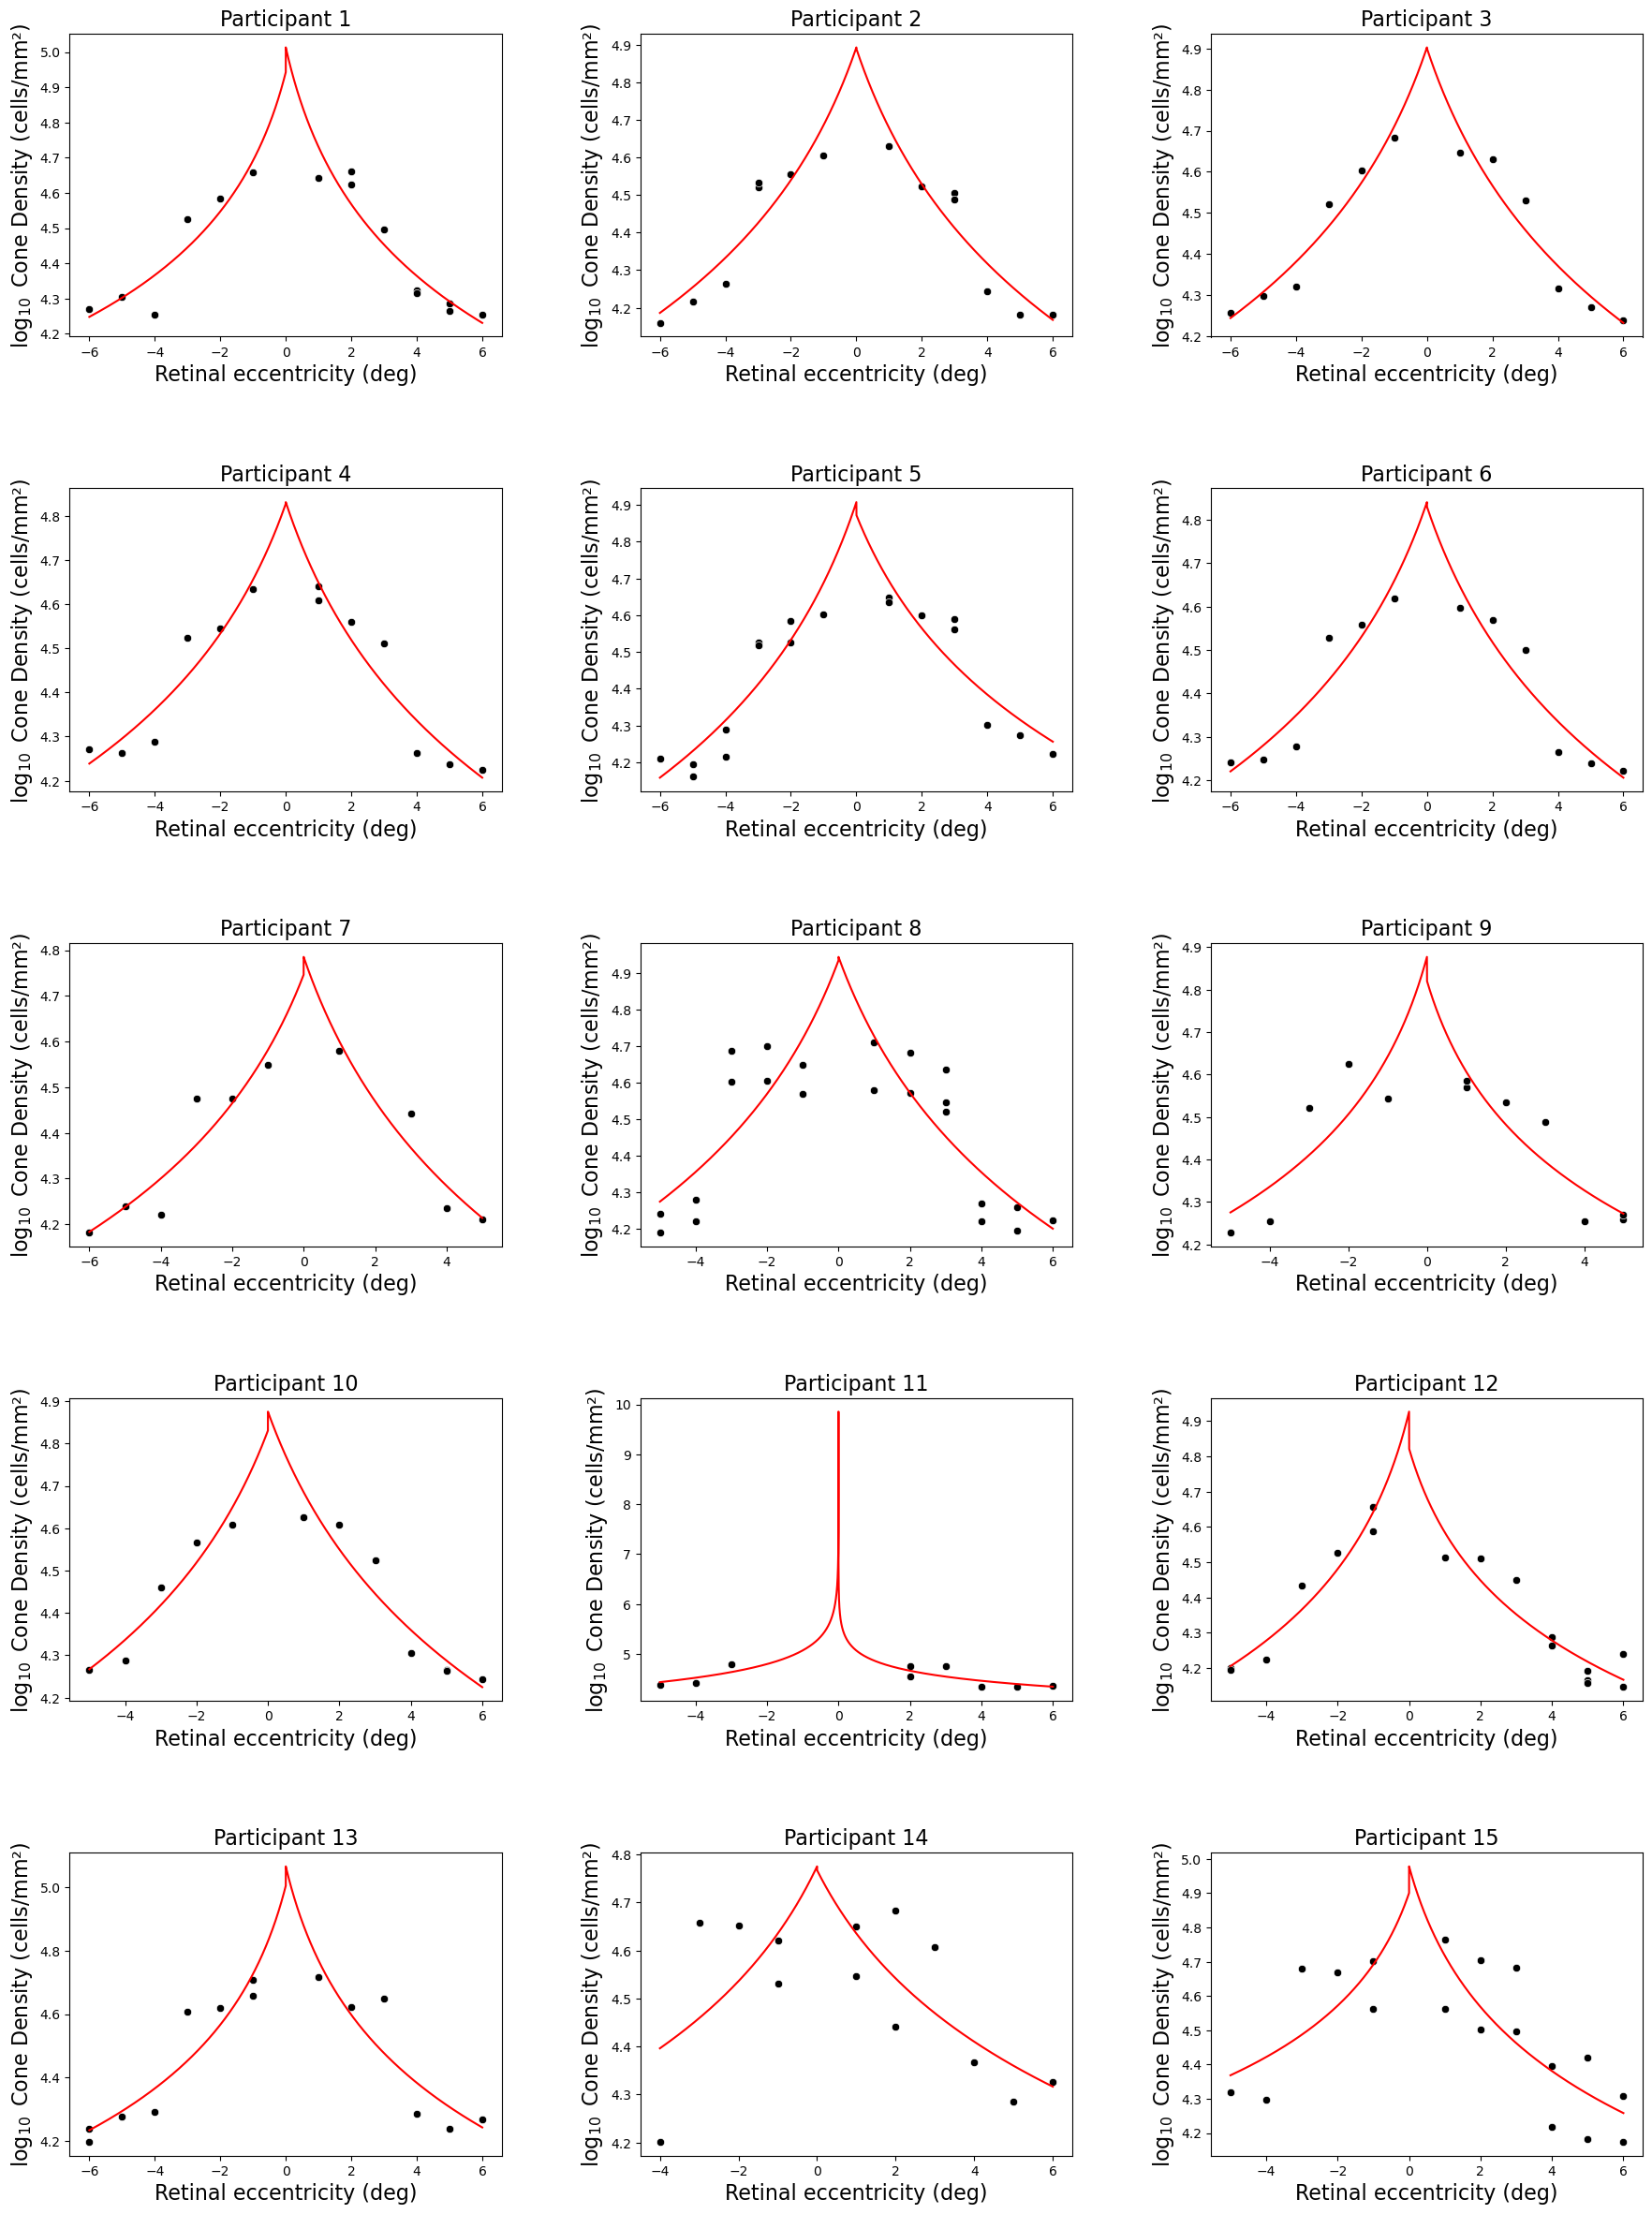

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit


def asymmetric_power_law(r_i, kappa, k_s, pi_n, pi_t, p_s, p_ns, p_ts, rho, r_s, e_i):
    """
    Asymmetric power law function for predicting density.

    Parameters:
    - r_i: Eccentricity (negative values for nasal)
    - kappa: Fixed effect intercept
    - k_s: Random intercept
    - pi_n: Fixed-effect exponent for the nasal visual field
    - pi_t: Fixed-effect exponent for the temporal visual field
    - p_s: Participant-specific fixed effect
    - p_ns: Random participant error for the nasal fixed effect
    - p_ts: Random participant error for the temporal fixed effect
    - rho: Fixed offset
    - r_s: Random offset

    Returns:
    - log(d_i): Log of predicted density
    """
    return np.where(
        r_i >= 0,
        kappa + k_s + ((pi_n + p_s) * np.log(np.abs(r_i) + (rho + r_s))) + e_i,
        kappa + k_s + ((pi_n - pi_t + p_ns - p_ts) * np.log(rho + r_s) + 
                      (pi_t + p_ts) * np.log(np.abs(r_i) + (rho + r_s))) + e_i
    )
# Setting up the subplots
nrows, ncols = 5, 3
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 24))
axs = axs.flatten()  # Flatten to easily iterate over all subplots

# Loop through each AOSLO and corresponding axis
for i, AOSLO in enumerate(AOSLO_list):
    # Read the data from CSV
    data = pd.read_csv(f'~/thesis_src/calculated_modality/analysis/csv_files/{AOSLO}.csv')
    
    data[['DegreeX', 'DegreeY']] = data['Degree'].str.strip('()').str.split(', ', expand=True)
    data['DegreeX'] = data['DegreeX'].astype(float)
    data['DegreeY'] = data['DegreeY'].astype(float)

    # Filter the data to include only points where the y-coordinate is 0 and within the x range [-6, 6]
    #data_filtered = data[(data['DegreeY'] == 0) & (data['DegreeX'] >= -6) & (data['DegreeX'] <= 6)].copy()
    data_filtered = data[(data['DegreeY'] == 0) & (data['DegreeX'] >= -6) & (data['DegreeX'] <= 6) & (data['DegreeX'] != 0)].copy()
   

    # Extract x-coordinates and y-values for fitting
    x = data_filtered['DegreeX'].values
    y = data_filtered['Predicted Cell Density'].values




    # Initial parameter guess
    p0 = [0, 0, -0.5, -0.5, 0, 0, 0, 0.1, 0, 0]

    # Parameter bounds
    bounds = ([-6, -1, -1, -1, -1, -1, -1, 0.01, -1, -1], [6, 1, 0, 0, 1, 1, 1, 1, 1, 1])

    
    # Fit the asymmetric power function
    popt, _ = curve_fit(asymmetric_power_law, x, y, p0=p0, bounds=bounds, maxfev=100000)

    # Generate x values for plotting the fitted function
    x_fit = np.linspace(min(x), max(x), 900000) # -6 to +6
    #print(x_fit)
    y_fit = asymmetric_power_law(x_fit, *popt)

    # Scatter plot of the original data
    sns.scatterplot(x=x, y=y, marker="o", color="black", ax=axs[i])

    # Plot the fitted asymmetric power function
    axs[i].plot(x_fit, y_fit, color='red')

    # Set the title for each subplot
    axs[i].set_title(f'Participant {i+1}', fontsize=16)

    # Setting common labels
    axs[i].set_xlabel("Retinal eccentricity (deg)", fontsize=16)
    axs[i].set_ylabel(r"$\log_{10}$ Cone Density (cells/mm²)", fontsize=16)

# Adjust layout to prevent overlap
#plt.tight_layout()
plt.tight_layout(pad=2.0, w_pad=6, h_pad=6)
plt.show()

if not os.path.exists('plots'):
    os.makedirs('plots')

fig.savefig('plots/calculated_2d_plots.png', format='png', dpi=300, bbox_inches='tight')


# 3D plot using calculated images

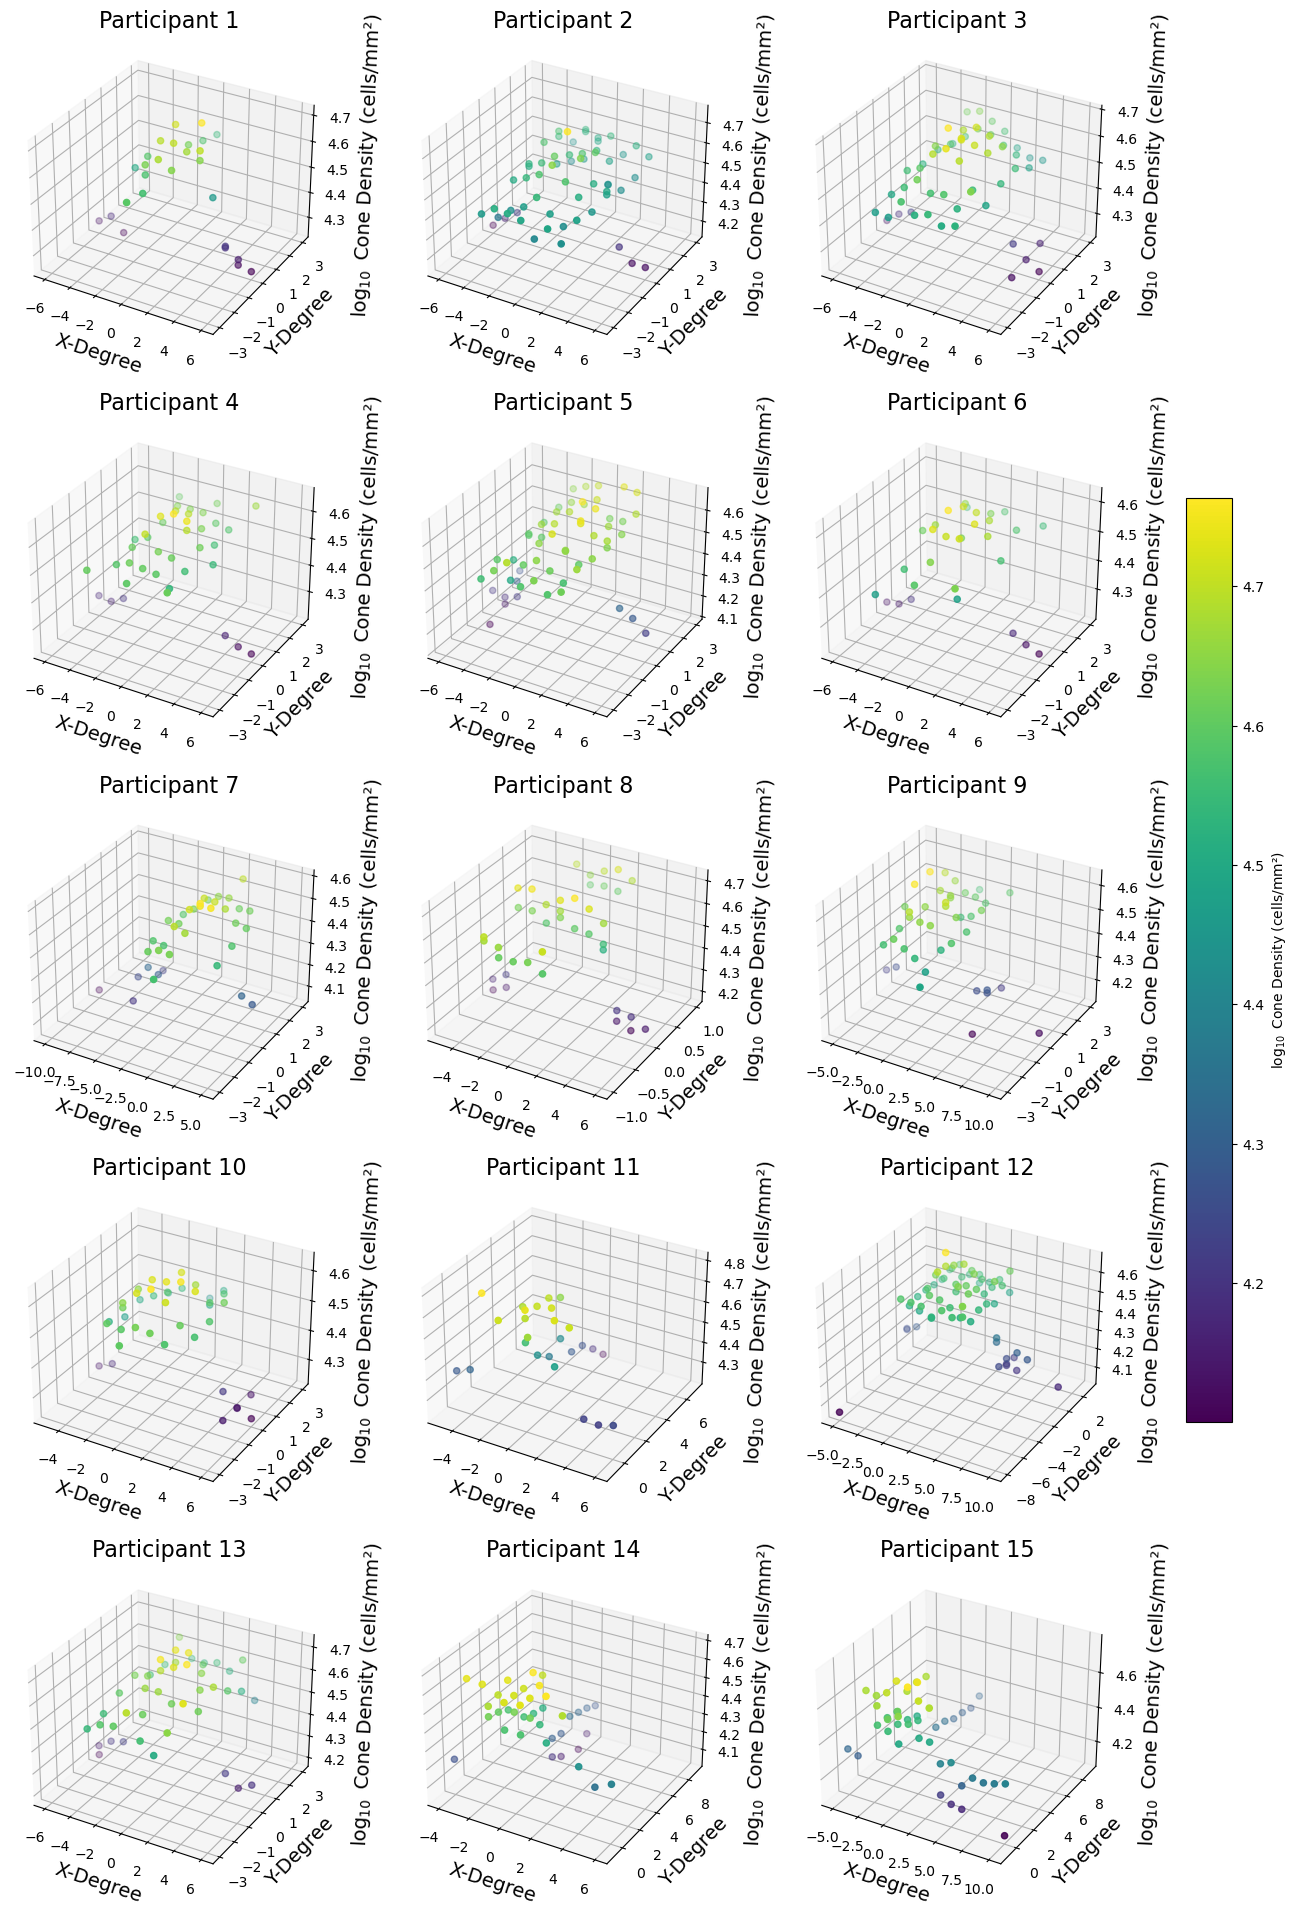

In [11]:

fig = plt.figure(figsize=(18, 24))

for i, AOSLO in enumerate(AOSLO_list):
    # Read the data from CSV
    data = pd.read_csv(f'~/thesis_src/calculated_modality/analysis/csv_files/{AOSLO}.csv')

    # Extract DegreeX and DegreeY from the 'Degree' column
    data[['DegreeX', 'DegreeY']] = data['Degree'].str.strip('()').str.split(', ', expand=True)
    data['DegreeX'] = data['DegreeX'].astype(int)
    data['DegreeY'] = data['DegreeY'].astype(int)

    # Add a subplot for each AOSLO
    ax = fig.add_subplot(nrows, ncols, i + 1, projection='3d')

    # Scatter plot with color mapping
    sc = ax.scatter(data['DegreeX'], data['DegreeY'], data['Predicted Cell Density'],
                    c=data['Predicted Cell Density'], cmap='viridis', marker='o')

    # Set axis labels and title
    ax.set_xlabel('X-Degree',  fontsize=14)
    ax.set_ylabel('Y-Degree',  fontsize=14)
    ax.set_zlabel(r"$\log_{10}$ Cone Density (cells/mm²)", fontsize=14)
    ax.set_title(f'Participant {i+1}',  fontsize=16)

# Add a color bar to the entire figure
fig.colorbar(sc, ax=fig.get_axes(), shrink=0.5, aspect=20, label=r"$\log_{10}$ Cone Density (cells/mm²)")


#plt.tight_layout()
plt.show()

if not os.path.exists('plots'):
    os.makedirs('plots')

fig.savefig('plots/calculated_3d_plots.png', format='png', dpi=300, bbox_inches='tight')

# Contour plots for calculated images

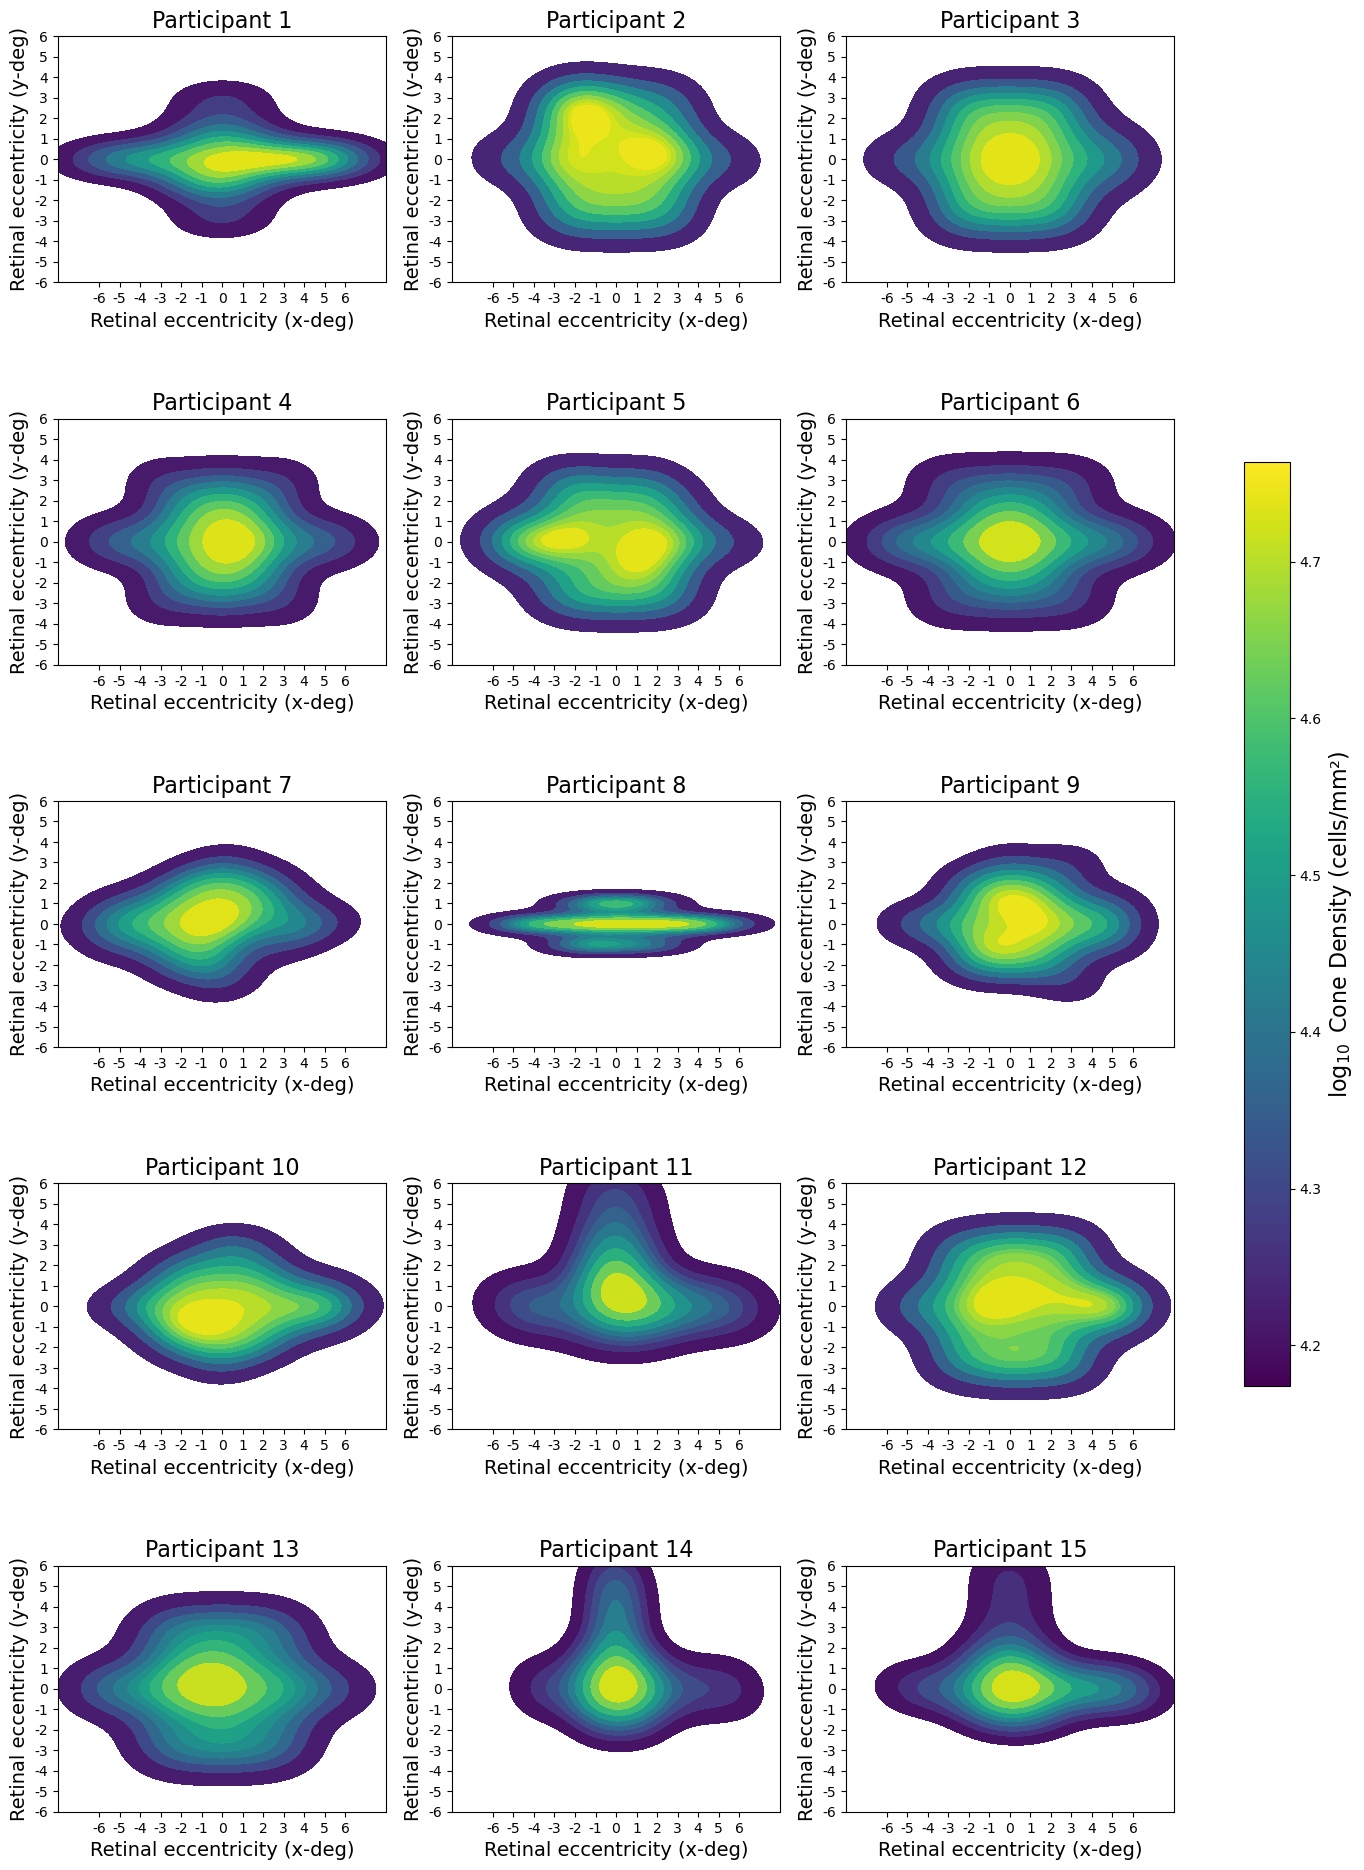

In [12]:
# Setting up the subplots
nrows, ncols = 5, 3
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 24))
axs = axs.flatten()  # Flatten to easily iterate over all subplots

x_ticks = range(-6, 7)
y_ticks = range(-6, 7)

# Loop through each AOSLO and corresponding axis
for i, AOSLO in enumerate(AOSLO_list):
    # Read the data from CSV
    data = pd.read_csv(f'~/thesis_src/calculated_modality/analysis/csv_files/{AOSLO}.csv')

    # Extract DegreeX and DegreeY from the 'Degree' column
    data[['DegreeX', 'DegreeY']] = data['Degree'].str.strip('()').str.split(', ', expand=True)
    data['DegreeX'] = data['DegreeX'].astype(int)
    data['DegreeY'] = data['DegreeY'].astype(int)
    

    # Filter the data
    filtered_data = data[(data['DegreeX'] >= -6) & (data['DegreeX'] <= 6) &
                         (data['DegreeY'] >= -6) & (data['DegreeY'] <= 6)]


    # Create a contour plot
    sns.kdeplot(
        x=filtered_data['DegreeX'], y=filtered_data['DegreeY'], 
        weights=filtered_data['Predicted Cell Density'], cmap="viridis", fill=True, ax=axs[i]
    )


    # Set axis labels
    axs[i].set_xlabel("Retinal eccentricity (x-deg)",  fontsize=14)
    axs[i].set_ylabel("Retinal eccentricity (y-deg)",  fontsize=14)
    axs[i].set_xticks(x_ticks)
    axs[i].set_xticklabels(x_ticks)
    axs[i].set_yticks(y_ticks)
    axs[i].set_yticklabels(y_ticks)
    
    axs[i].set_aspect('equal', adjustable='box')
    axs[i].set_xlim([-8, 8])
    axs[i].set_ylim([-6, 6])
    axs[i].grid(False)
    axs[i].set_title(f'Participant {i+1}',  fontsize=16)
    

# Add a color bar to the entire figure
norm = plt.Normalize(vmin=filtered_data['Predicted Cell Density'].min(), vmax=filtered_data['Predicted Cell Density'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=fig.get_axes(), shrink=0.5, aspect=20) #, label=r"$\log_{10}$ Cone Density (cells/mm²)")
# cbar = fig.colorbar(sc, ax=axs, shrink=0.5, aspect=20)
cbar.set_label(r"$\log_{10}$ Cone Density (cells/mm²)", fontsize=16)

plt.show()


if not os.path.exists('plots'):
    os.makedirs('plots')
    
fig.savefig('plots/calculated_contour_plots.png', format='png', dpi=300, bbox_inches='tight')

# Average cone inner-segment area for calculated images

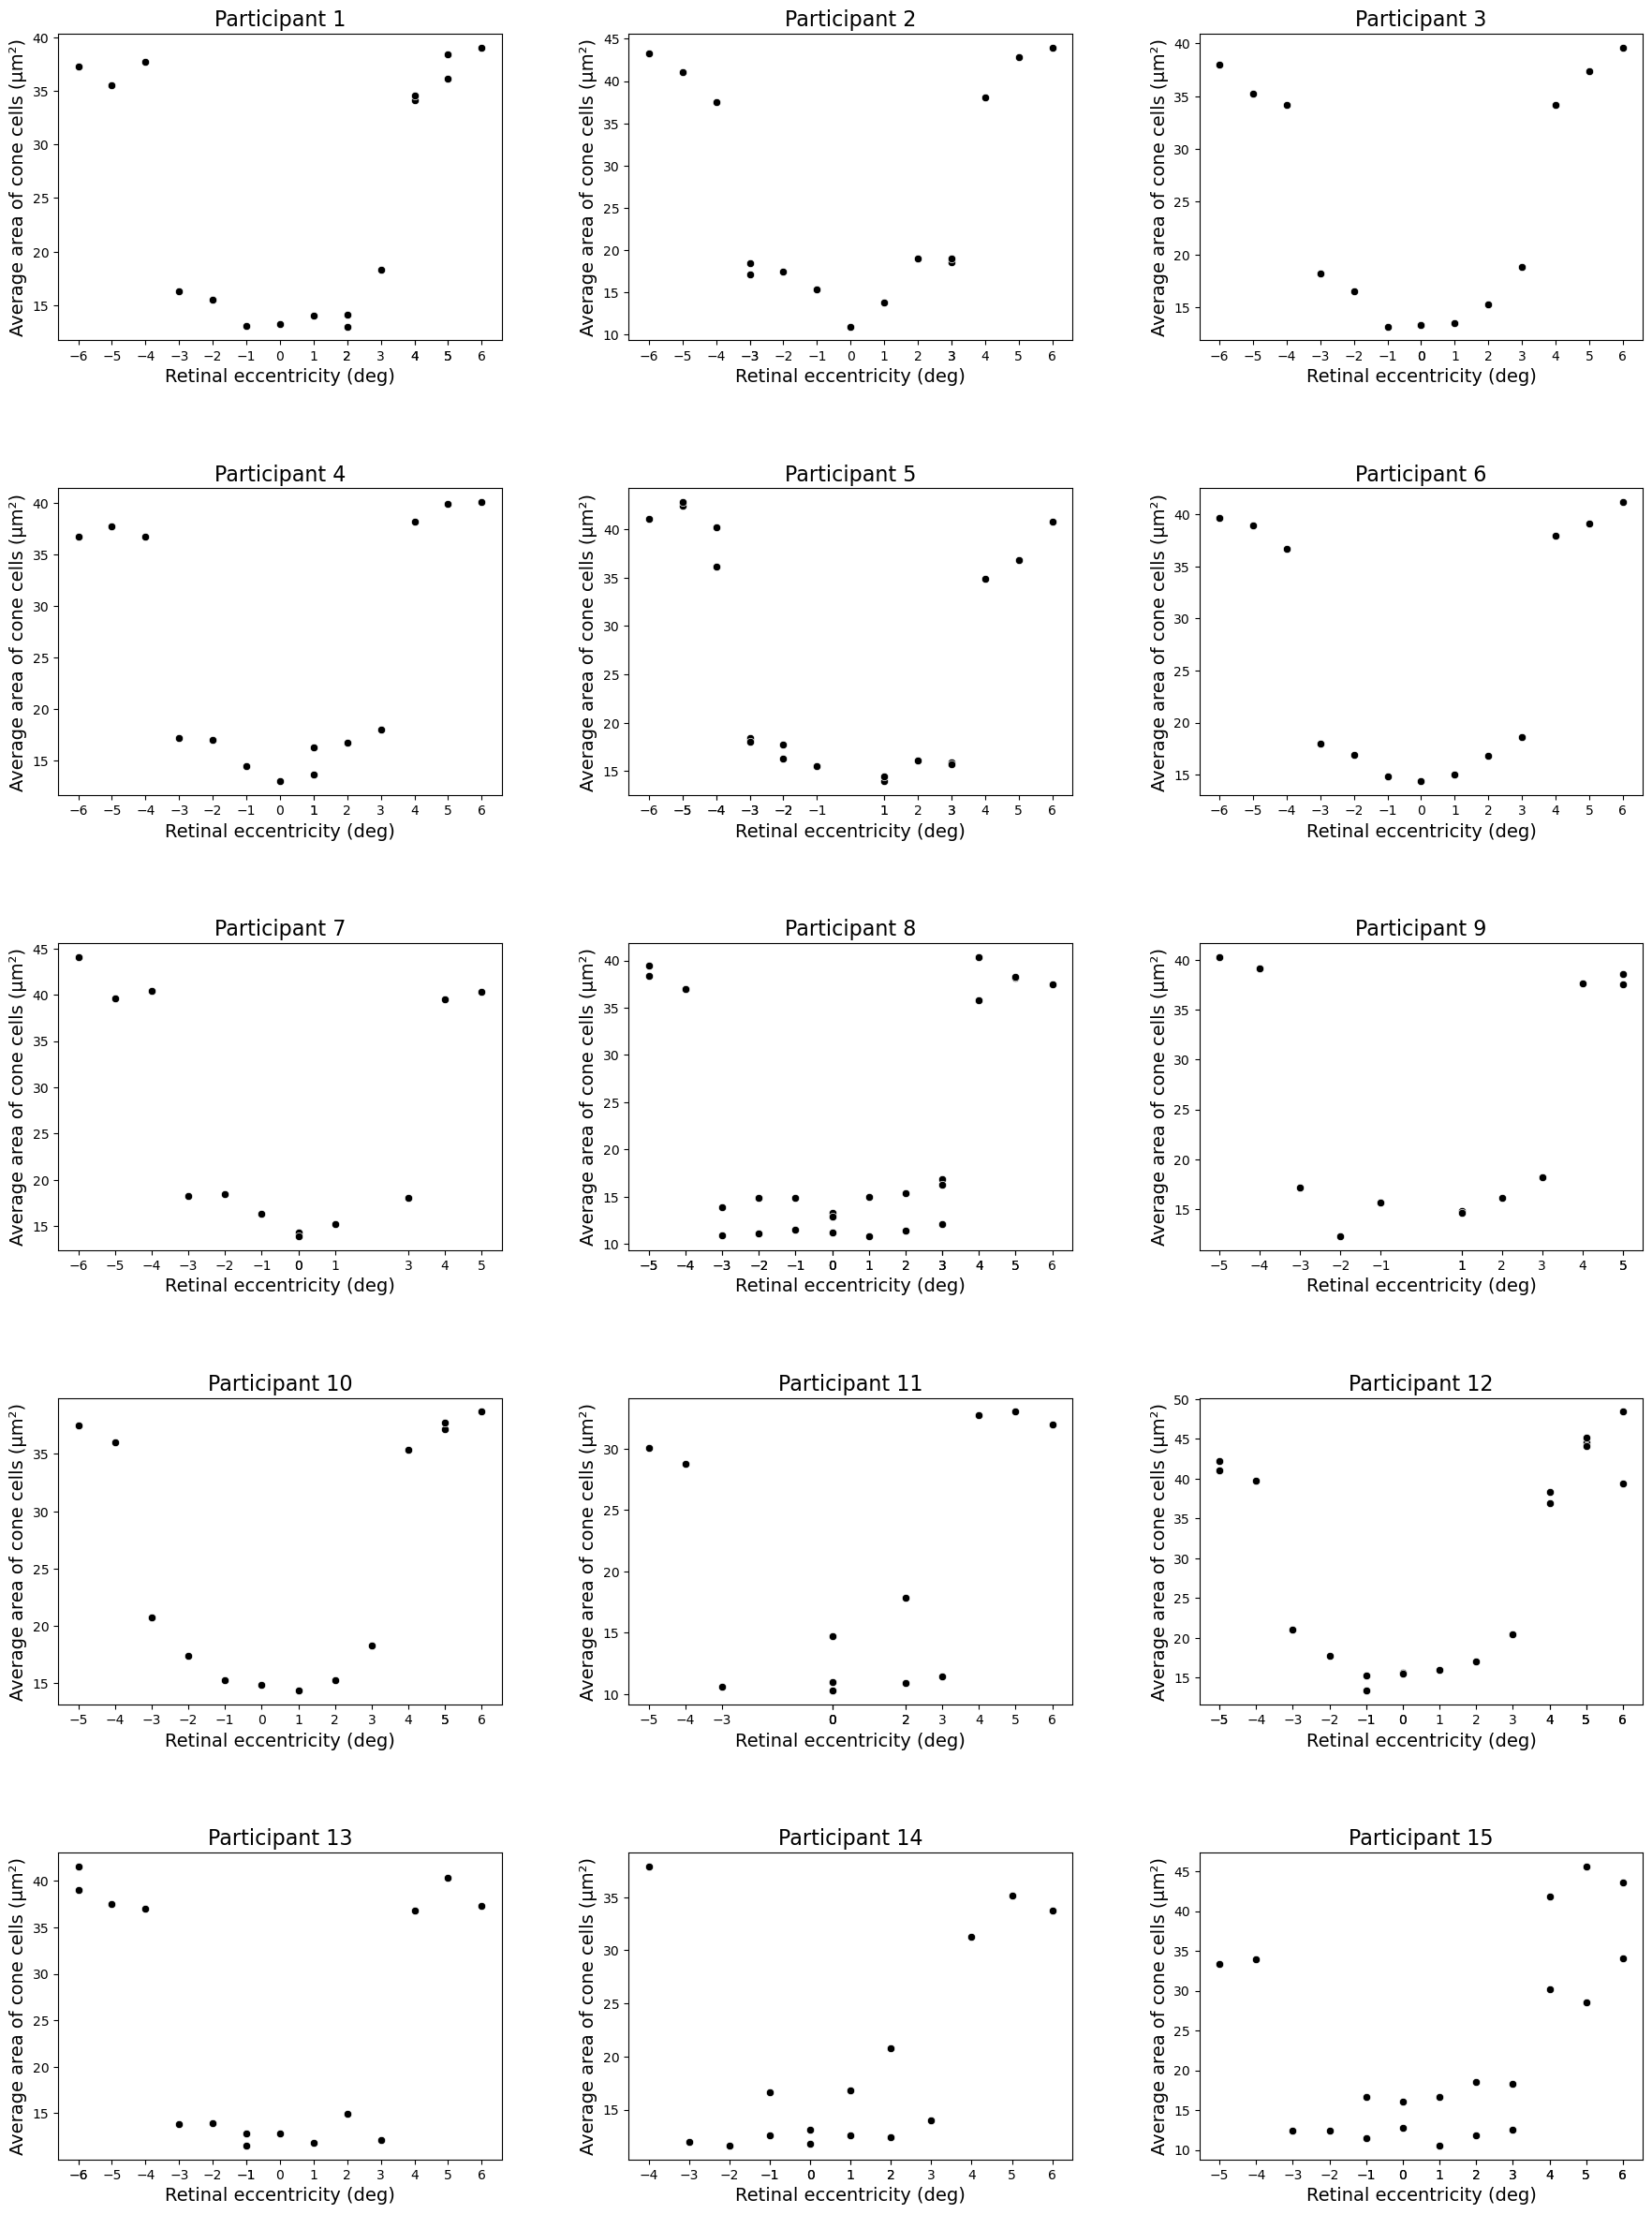

In [13]:
# Setting up the subplots
nrows, ncols = 5, 3
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 24))
axs = axs.flatten()  # Flatten to easily iterate over all subplots

# Loop through each AOSLO and corresponding axis
for i, AOSLO in enumerate(AOSLO_list):
    # Read the data from CSV
    data = pd.read_csv(f'~/thesis_src/calculated_modality/analysis/csv_files/{AOSLO}.csv')
    
    data[['DegreeX', 'DegreeY']] = data['Degree'].str.strip('()').str.split(', ', expand=True)
    data['DegreeX'] = data['DegreeX'].astype(int)
    data['DegreeY'] = data['DegreeY'].astype(int)

    # Filter the data to include only points where the y-coordinate is 0 and within the x range [-6, 6]
    data_filtered = data[(data['DegreeY'] == 0) & (data['DegreeX'] >= -6) & (data['DegreeX'] <= 6)].copy()

    # Extract x-coordinates for plotting
    data_filtered['X'] = data_filtered['DegreeX']

    # Scatter plot of the original data
    sns.scatterplot(x=data_filtered['X'], y=data_filtered['Average Cell Area'], marker="o", color="black", ax=axs[i])
    

    # Setting common labels
    axs[i].set_xlabel("Retinal eccentricity (deg)",  fontsize=14)
    axs[i].set_xticks(data_filtered['X'])
    #axs[i].set_xticklabels(data['Degree'], rotation=90)
    axs[i].set_ylabel("Average area of cone cells (μm²)",  fontsize=14)
    axs[i].grid(False)
    axs[i].set_title(f'Participant {i+1}',  fontsize=16)

# Adjust layout to prevent overlap
#plt.tight_layout()
plt.tight_layout(pad=2.0, w_pad=6, h_pad=6)

plt.show()

if not os.path.exists('plots'):
    os.makedirs('plots')

fig.savefig('plots/calculated_area_plots.png', format='png', dpi=300, bbox_inches='tight')